In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

DATA ANYLISIS OF MEDICINE DETAILS

In [2]:
df=pd.read_csv(r'C:\Users\Admin\Downloads\Medicine_Details.csv',encoding='latin1')
print(df.head())

              Medicine Name  \
0   Avastin 400mg Injection   
1  Augmentin 625 Duo Tablet   
2       Azithral 500 Tablet   
3          Ascoril LS Syrup   
4         Aciloc 150 Tablet   

                                         Composition  \
0                                Bevacizumab (400mg)   
1    Amoxycillin  (500mg) +  Clavulanic Acid (125mg)   
2                               Azithromycin (500mg)   
3  Ambroxol (30mg/5ml) + Levosalbutamol (1mg/5ml)...   
4                                 Ranitidine (150mg)   

                                                Uses  \
0   Cancer of colon and rectum Non-small cell lun...   
1                  Treatment of Bacterial infections   
2                  Treatment of Bacterial infections   
3                      Treatment of Cough with mucus   
4  Treatment of Gastroesophageal reflux disease (...   

                                        Side_effects  \
0  Rectal bleeding Taste change Headache Noseblee...   
1  Vomiting Nausea Diarrhea

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11825 entries, 0 to 11824
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Medicine Name       11825 non-null  object
 1   Composition         11825 non-null  object
 2   Uses                11825 non-null  object
 3   Side_effects        11825 non-null  object
 4   Image URL           11825 non-null  object
 5   Manufacturer        11825 non-null  object
 6   Excellent Review %  11825 non-null  int64 
 7   Average Review %    11825 non-null  int64 
 8   Poor Review %       11825 non-null  int64 
dtypes: int64(3), object(6)
memory usage: 831.6+ KB


CLEANING AND REMOVING DUPLICATES FROM DATASET

In [4]:
print(df.isnull().sum())
df.drop_duplicates(inplace=True)
print(df.info())

Medicine Name         0
Composition           0
Uses                  0
Side_effects          0
Image URL             0
Manufacturer          0
Excellent Review %    0
Average Review %      0
Poor Review %         0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Int64Index: 11741 entries, 0 to 11823
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Medicine Name       11741 non-null  object
 1   Composition         11741 non-null  object
 2   Uses                11741 non-null  object
 3   Side_effects        11741 non-null  object
 4   Image URL           11741 non-null  object
 5   Manufacturer        11741 non-null  object
 6   Excellent Review %  11741 non-null  int64 
 7   Average Review %    11741 non-null  int64 
 8   Poor Review %       11741 non-null  int64 
dtypes: int64(3), object(6)
memory usage: 917.3+ KB
None


TOTAL NUMBER OF MEDICINE IN DATA

In [5]:
print(df['Medicine Name'].count())


11741


NAMES OF THE MANUFACTURER

In [6]:
manu=np.unique(df['Manufacturer'])
print(manu)

['A. Menarini India Pvt Ltd' 'AAA Pharma Trade Pvt Ltd'
 'ADN Life Sciences' 'ADZO Lifesciences Pvt Ltd'
 'AGIO Pharmaceuticals Ltd' 'AN Pharmaceuticals Pvt Ltd' 'AS Lifesciences'
 'Aareen Healthcare Pvt Ltd' 'Aarti Life Science' 'Abbott' 'Aceon Pharma'
 'Acme Generics LLP' 'Acmedix Pharma LLP' 'Adalbert Healthcare Pvt Ltd'
 'Adley Formulations' 'Adonis Laboratories Pvt Ltd'
 'Adonis Phytoceuticals Pvt Ltd' 'Adroit Biomed Ltd'
 'Aeobury Healthcare Pvt Ltd' 'Aglowmed Limited' 'Agn Healthcare'
 'Ajanta Pharma Ltd' 'Akcent Healthcare' 'Akesiss Pharma Pvt Ltd'
 'Akognos Life Sciences' 'Aksigen Hospital Care'
 'Akumentis Healthcare Ltd' 'Alaxia Healthcare' 'Albert David Ltd'
 'Albia Biocare' 'Alchem Phytoceuticals Ltd' 'Alcon Laboratories'
 'Alembic Pharmaceuticals Ltd' 'Algen Healthcare Limited'
 'Alive Pharmaceutical Pvt Ltd' 'Alkem Laboratories Ltd'
 'Allergan India Pvt Ltd' 'Alliance Remedies' 'Alna Biotech Pvt Ltd'
 'Alniche Life Sciences Pvt Ltd' 'Altavista Life Sciences Pvt Ltd'
 'Al

DIFFERENT TYPE OF COMPOSITION

In [7]:
comp=np.unique(df['Composition'])
print(comp)

['Abacavir (600mg) + Lamivudine (300mg)' 'Abiraterone Acetate (250mg)'
 'Abiraterone Acetate (500mg)' ... 'Zonisamide (50mg)'
 'n-Butyl-2-cyanoacrylate (0.5ml)' 'silver nano particles (0.002% w/w)']


MANUFACTURER WHICH HAVE MANY MEDICINE AND VERY FREQUENT

In [8]:
manufact=df["Manufacturer"].value_counts().idxmax()
print(manufact)

Sun Pharmaceutical Industries Ltd


In [9]:
top_manufacturer=df['Manufacturer'].value_counts().sort_values(ascending=False).head(10)
print(top_manufacturer)

Sun Pharmaceutical Industries Ltd    819
Intas Pharmaceuticals Ltd            648
Cipla Ltd                            569
Torrent Pharmaceuticals Ltd          441
Lupin Ltd                            432
Mankind Pharma Ltd                   336
Zydus Cadila                         326
Alkem Laboratories Ltd               325
Macleods Pharmaceuticals Pvt Ltd     316
Abbott                               279
Name: Manufacturer, dtype: int64


MOST OF COMPOSITION USED

In [10]:
common_composition=df['Composition'].value_counts().head()
print(common_composition)

Luliconazole (1% w/w)                        98
Levocetirizine (5mg) + Montelukast (10mg)    76
Ketoconazole (2% w/w)                        61
Domperidone (30mg) + Rabeprazole (20mg)      59
Itraconazole (100mg)                         53
Name: Composition, dtype: int64


In [11]:
same_composition=df.groupby('Composition')['Medicine Name'].nunique().sort_values(ascending=False)
print(same_composition.head(10))

Composition
Levocetirizine (5mg) + Montelukast (10mg)    76
Luliconazole (1% w/w)                        64
Domperidone (30mg) + Rabeprazole (20mg)      59
Ketoconazole (2% w/w)                        58
Telmisartan (40mg)                           51
Itraconazole (100mg)                         48
Domperidone (30mg) + Pantoprazole (40mg)     47
Itraconazole (200mg)                         47
Telmisartan (40mg) + Amlodipine (5mg)        43
Metformin (500mg)                            42
Name: Medicine Name, dtype: int64


MOST COMMON DISEASE OR CONDITIONS

In [12]:
common_disease=df['Uses'].value_counts().head(10)
print(common_disease)

Treatment of Type 2 diabetes mellitus                                                          904
Treatment of Bacterial infections                                                              434
 Hypertension (high blood pressure)                                                            403
 Pain relief                                                                                   381
Treatment of Hypertension (high blood pressure)                                                277
Treatment of Fungal skin infections                                                            216
Treatment of Neuropathic pain                                                                  185
Treatment of Fungal infections                                                                 179
Treatment of Gastroesophageal reflux disease (Acid reflux)Treatment of Peptic ulcer disease    175
 Fungal skin infections                                                                        141
Name: Uses

MEDICINCE USE IN MANY CONDITIONS

In [13]:
df['condition_count']=df['Uses'].str.split(",").str.len()
multi_condition=df[df['condition_count']>1]
print(multi_condition[['Medicine Name','Uses','condition_count']].head(10))

             Medicine Name                                               Uses  \
1545  DO RE ME 25mg Tablet  Treatment of Anxiety disorderTreatment of $nam...   
1656  DO RE ME 75mg Tablet  Treatment of Anxiety disorderTreatment of $nam...   
1663  DO RE ME 50mg Tablet  Treatment of Anxiety disorderTreatment of $nam...   
7270     Osule 25mg Tablet  Treatment of Anxiety disorderTreatment of $nam...   
7357   Prevenar 13 Vaccine   Prevention of pneumonia, meningitis, blood in...   
7388     Prothiaden Tablet  Treatment of Anxiety disorderTreatment of $nam...   
7440  Pneumovax 23 Vaccine   Prevention of pneumonia, meningitis, blood in...   
7493  Prothiaden 75 Tablet  Treatment of Anxiety disorderTreatment of $nam...   
7501  Prothiaden 50 Tablet  Treatment of Anxiety disorderTreatment of $nam...   
9172     Synflorix Vaccine   Prevention of pneumonia, meningitis, blood in...   

      condition_count  
1545                4  
1656                4  
1663                4  
7270        

SIDE EFFECT WHICH VERY FREQUENT

In [14]:
h_side_effect=df['Side_effects'].value_counts().idxmax()
print(h_side_effect)

Application site reactions burning irritation itching and redness


AVERAGE COUNT FOR MEDICINE SIDE EFFECT

In [15]:
avg_effect=df.groupby("Medicine Name")['Side_effects'].value_counts().mean()
print(avg_effect)

1.0210453082876771


TOP RATED MEDICINE

In [16]:
top_rated_medicine=df.sort_values('Excellent Review %',ascending=False)
print(top_rated_medicine['Medicine Name'].head())

3212    Glimital-M1 Forte Tablet PR
9435          Sucrapen-O Suspension
682                  Anabrez Tablet
4941          Levomil 40 Capsule ER
2148                    Esys Tablet
Name: Medicine Name, dtype: object


POOR RATED MEDICINCES

In [17]:
poor_rated_medicine=df.sort_values('Poor Review %',ascending=False)
print(poor_rated_medicine['Medicine Name'].head())

11823                 Zedruff Shampoo
3741      Irimist Ophthalmic Solution
412                    Avas 40 Tablet
8250                Rabemac Mps Syrup
3653     Intacoxia MR 60mg/4mg Tablet
Name: Medicine Name, dtype: object


DISTRIBUTION OF ALL TYPE OF REVIEW

Excellent Review %    38.505068
Average Review %      35.783494
Poor Review %         25.711439
dtype: float64


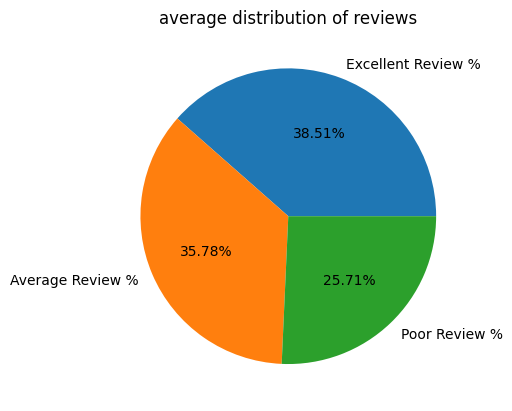

In [18]:
review_distribution=df[["Excellent Review %","Average Review %","Poor Review %"]].mean()
print(review_distribution)
review_distribution.plot(kind='pie',autopct='%.2f%%')
plt.title("average distribution of reviews")
plt.show()

AVERAGE REVIEW FOR EACH MANUFACTURER

In [19]:
review_per_manu=(df.groupby('Manufacturer')['Average Review %'].sum())
review_per_manu=(review_per_manu/review_per_manu.sum())*100
review_per_manu=review_per_manu.sort_values(ascending=False)
print(review_per_manu.head())

Manufacturer
Sun Pharmaceutical Industries Ltd    7.603765
Intas Pharmaceuticals Ltd            5.761733
Cipla Ltd                            5.177396
Torrent Pharmaceuticals Ltd          3.912561
Lupin Ltd                            3.703580
Name: Average Review %, dtype: float64


BAR GRAPH SHOWN TOP 10 MANUFACTURER WITH THE MEDICINE

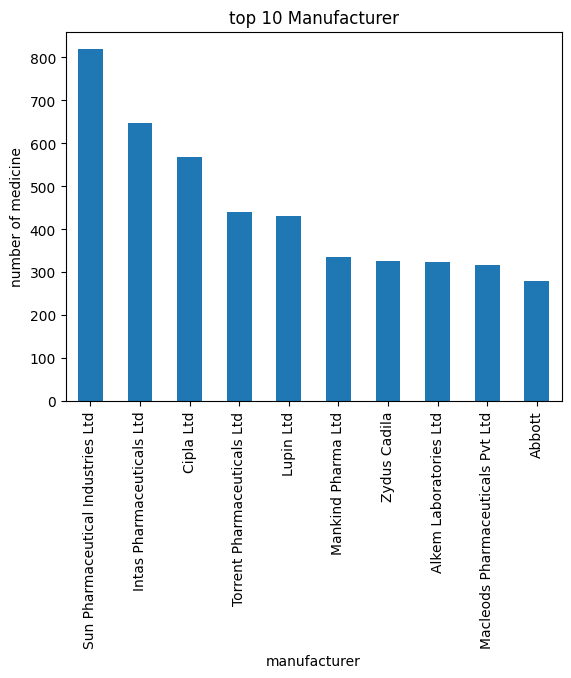

In [20]:
top_manufacturer.plot(kind='bar')
plt.title("top 10 Manufacturer")
plt.xlabel("manufacturer")
plt.ylabel("number of medicine")
plt.xticks(rotation=90)
plt.show()

BAR GRAPH SHOWS THE COMMONLY USE OR FREQUENTLY USE COMPOSITION IN MEDICINE

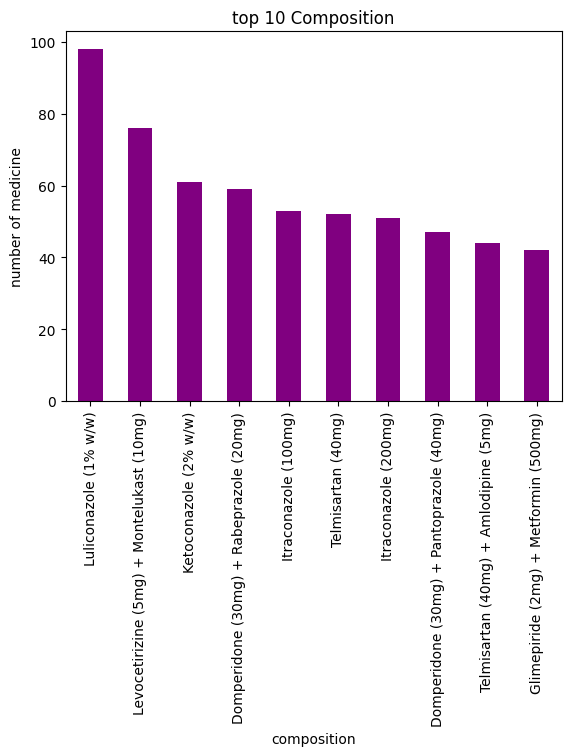

In [21]:
top_composition=df['Composition'].value_counts().sort_values(ascending=False).head(10)
top_composition.plot(kind="bar",color='purple')
plt.title("top 10 Composition")
plt.xlabel("composition")
plt.ylabel("number of medicine")
plt.xticks(rotation=90)
plt.show()

SHOWS MOST COMMMON SIDE EFFECT BY MEDICINE

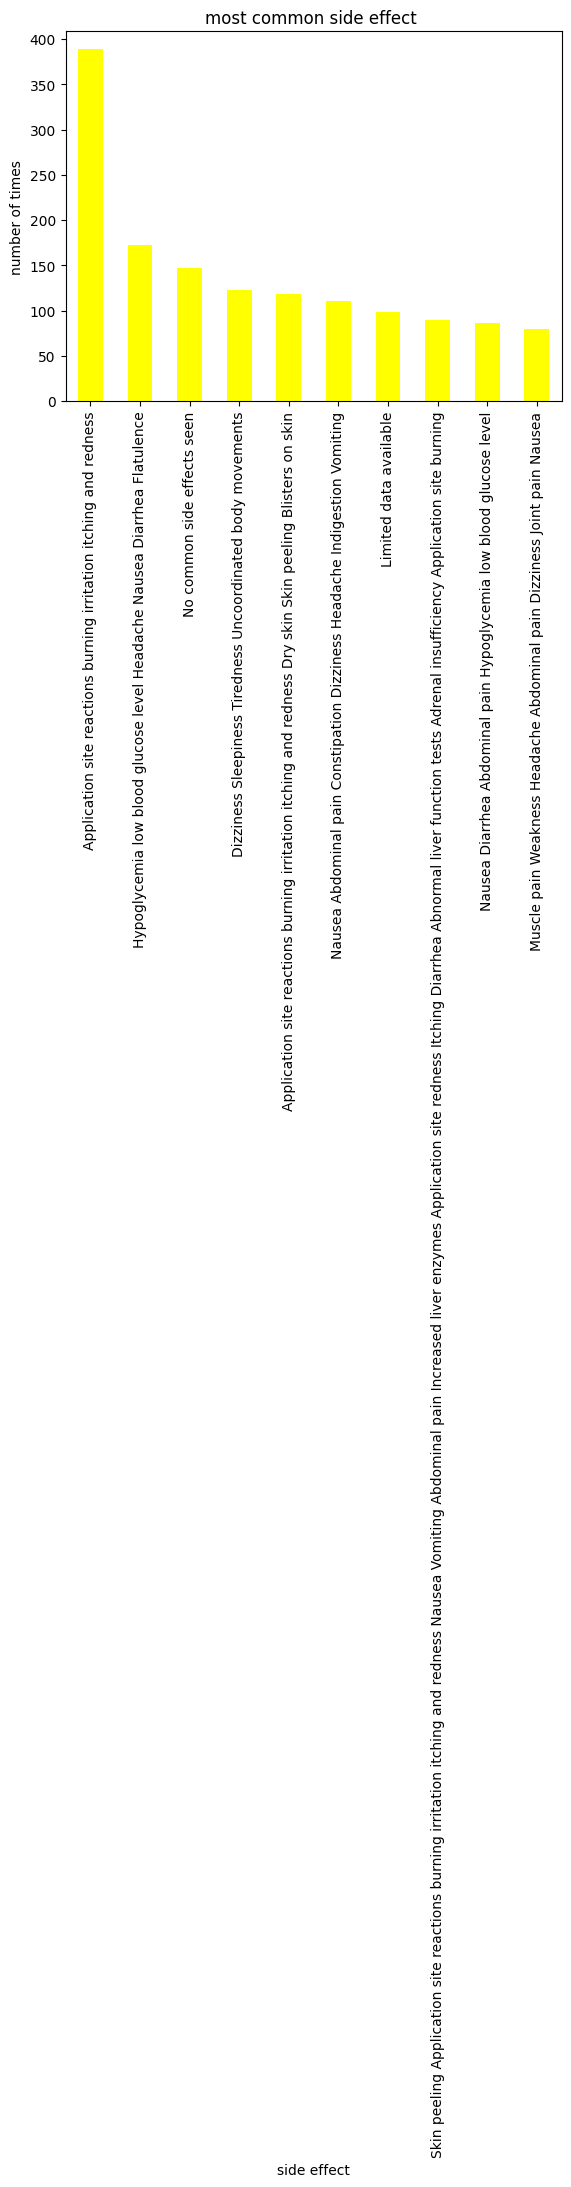

In [22]:
most_common_side_effect=df['Side_effects'].value_counts().sort_values(ascending=False).head(10)
most_common_side_effect.plot(kind="bar",color="yellow")
plt.title("most common side effect ")
plt.xlabel("side effect")
plt.ylabel("number of times")
plt.xticks(rotation=90)
plt.show()


HISTOGRAM SHOWS THE EXCELLENT REVIEW % WITH RESPECT TO THE MEDICINE COUNT

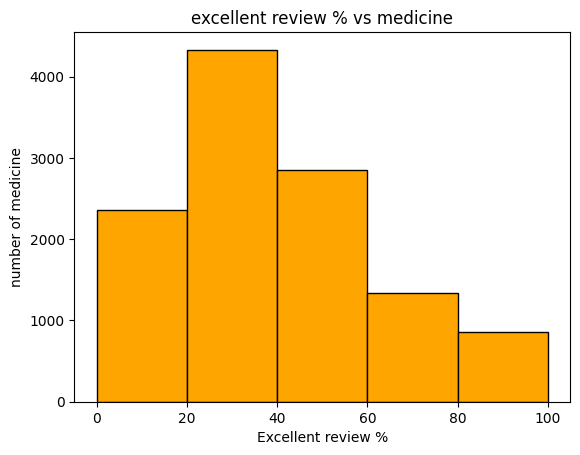

In [23]:
plt.hist(df["Excellent Review %"],bins=5,color='orange',edgecolor="black")
plt.title("excellent review % vs medicine")
plt.xlabel("Excellent review %")
plt.ylabel("number of medicine")

plt.show()

HISTOGRAM SHOWS THE POOR REVIEW % WITH RESPECT TO THE  NUMBER OF MEDICINE

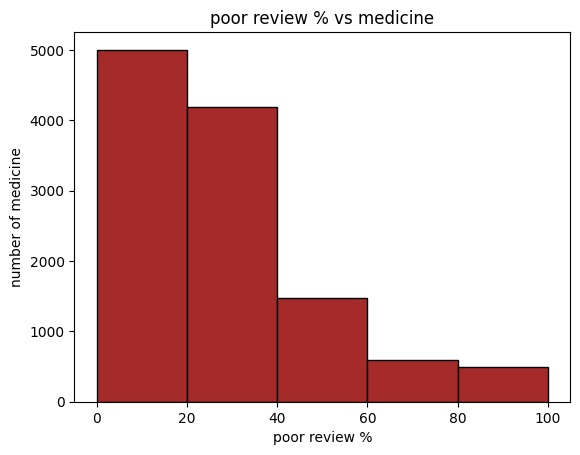

In [24]:
plt.hist(df["Poor Review %"],bins=5,color='brown',edgecolor="black")
plt.title("poor review % vs medicine")
plt.xlabel("poor review %")
plt.ylabel("number of medicine")

plt.show()

BOXPLOT SHOW THE MOST OF COMMON RANGE OF EXCELLENT RATING

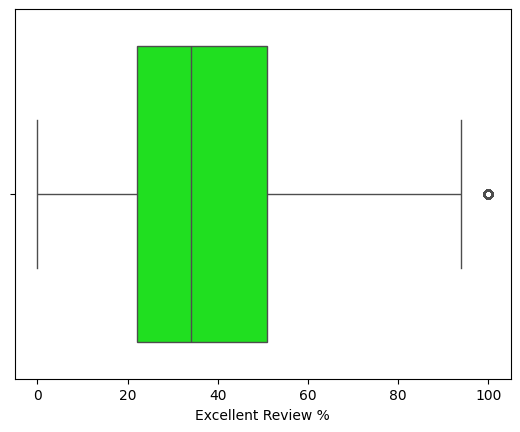

In [25]:

sns.boxplot(data=df,x='Excellent Review %',color='lime')
plt.show()


heatmap correlation with type of review

C:\Users\Admin\AppData\Local\Temp\ipykernel_10388\644741912.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_block = df.corr(method='pearson')


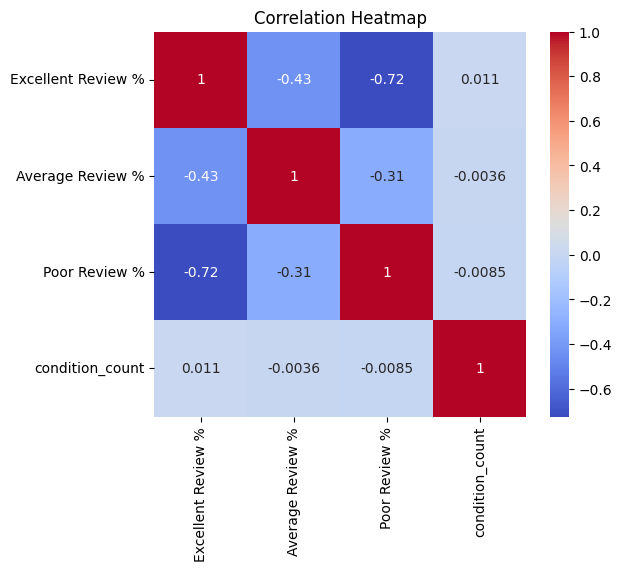

In [26]:
corr_block = df.corr(method='pearson')

plt.figure(figsize=(6,5))
sns.heatmap(corr_block, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#  Insights

After performing exploratory data analysis on the medicine dataset, the following key insights were observed:

1. The dataset contains **11,825 medicine records** from **759 pharmaceutical manufacturers**, representing a diverse range of medicines and healthcare products.

2. **Sun Pharmaceutical Industries Ltd** is the leading manufacturer in the dataset, followed by other major pharmaceutical companies, indicating that a few manufacturers contribute a significant portion of the medicines.

3. The analysis of medicine compositions shows that some active ingredient combinations are prescribed much more frequently than others, while many compositions are unique, highlighting the diversity of pharmaceutical formulations.

4. Customer review analysis reveals that **Excellent Reviews have the highest average percentage**, suggesting that most medicines receive positive feedback from users.

5. The distribution of Excellent and Poor Review percentages indicates that the majority of medicines maintain consistent customer satisfaction, with only a small number of medicines receiving extremely high or low ratings.

6. Side effect analysis identifies several commonly reported side effects shared across multiple medicines, providing useful insights into frequently observed adverse reactions.

7. The box plot highlights the presence of a few outliers in Excellent Review percentages, while most medicines are concentrated within a moderate review range.

8. The correlation heatmap shows a strong negative relationship between **Excellent Review %** and **Poor Review %**, indicating that medicines with higher positive reviews generally receive fewer negative reviews.

9. Overall, the dataset demonstrates a broad pharmaceutical landscape with diverse manufacturers, compositions, therapeutic uses, and customer feedback, making it valuable for healthcare analytics and pharmaceutical market research.

#  Conclusion

This exploratory data analysis of the medicine dataset provided valuable insights into pharmaceutical manufacturers, medicine compositions, customer review patterns, and common side effects. The analysis revealed that a small number of manufacturers contribute a large share of the medicines, while customer feedback is generally positive, with Excellent Reviews outweighing Poor Reviews.

The visualizations—including bar charts, pie charts, histograms, box plots, and a Pearson correlation heatmap—helped uncover meaningful patterns and relationships within the data. In particular, the strong negative correlation between Excellent Review % and Poor Review % indicates that medicines with higher positive ratings tend to receive fewer negative reviews.

Overall, this project demonstrates how Python and data visualization techniques can transform raw healthcare data into actionable insights. The findings can support pharmaceutical market analysis, customer satisfaction assessment, and future healthcare analytics projects. This analysis also provides a solid foundation for advanced applications such as medicine recommendation systems, predictive modeling, and interactive dashboards.